# Support Vector Machines

Let's create the same fake income / age clustered data that we used for our K-Means clustering example:

In [2]:
import numpy as np
np.set_printoptions(legacy='1.25')

In [4]:

#Create fake income/age clusters for N people in k clusters
def createClusteredData(N, k):
    np.random.seed(1234)
    pointsPerCluster = float(N)/k
    X = []
    y = []
    for i in range (k):
        # income centroid
        incomeCentroid = np.random.uniform(20000.0, 200000.0)
        # age centroid
        ageCentroid = np.random.uniform(20.0, 70.0)
        # appended randomly distributed around the income and age centroid
        for j in range(int(pointsPerCluster)):
            X.append([np.random.normal(incomeCentroid, 10000.0), np.random.normal(ageCentroid, 2.0)])
            y.append(i)
    X = np.array(X)
    y = np.array(y)
    return X, y

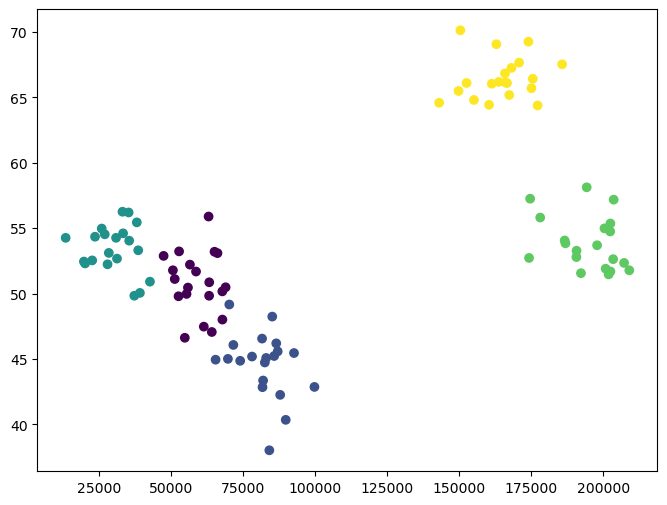

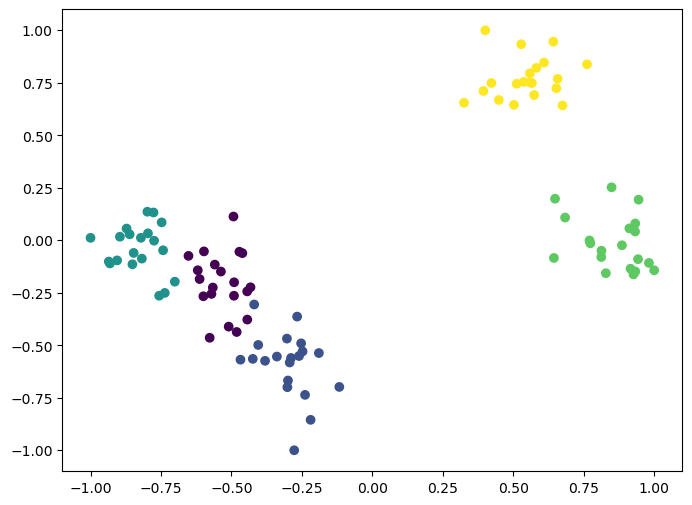

In [5]:
%matplotlib inline
from pylab import *
from sklearn.preprocessing import MinMaxScaler

(X, y) = createClusteredData(100, 5)

plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], c=y.astype(float))
plt.show()

# have to move the points and scale from -1 - +1
scaling = MinMaxScaler(feature_range=(-1,1)).fit(X)
X = scaling.transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], c=y.astype(float))
plt.show()

Now we'll use linear SVC to partition our graph into clusters:

In [6]:
#The types are: ‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’
#Linear: 
from sklearn import svm, datasets

C = 1.0
svc = svm.SVC(kernel='linear', C=C).fit(X, y)

In [ ]:
#Poly: 
from sklearn import svm, datasets

C = 1.0
svc = svm.SVC(kernel='poly', C=C).fit(X, y)

By setting up a dense mesh of points in the grid and classifying all of them, we can render the regions of each cluster as distinct colors:

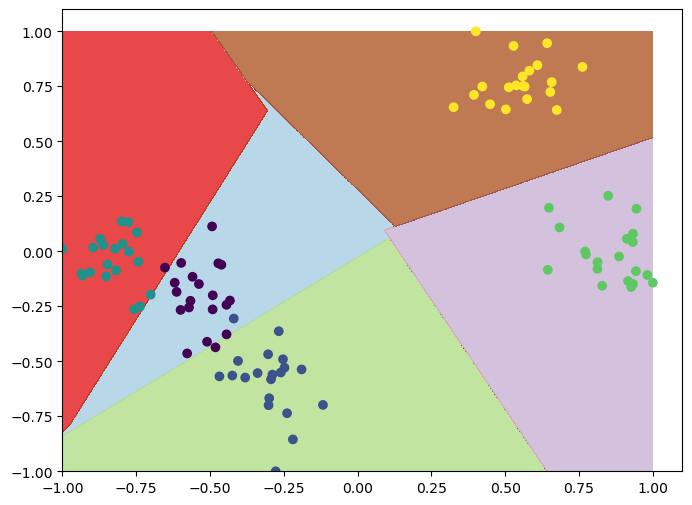

In [7]:
def plotPredictions(clf):
    # Create a dense grid of points to sample 
    xx, yy = np.meshgrid(np.arange(-1, 1, .001),
                     np.arange(-1, 1, .001))
    
    # Convert to Numpy arrays
    npx = xx.ravel()
    npy = yy.ravel()
    
    # Convert to a list of 2D (income, age) points
    samplePoints = np.c_[npx, npy]
    
    # Generate predicted labels (cluster numbers) for each point
    Z = clf.predict(samplePoints)

    plt.figure(figsize=(8, 6))
    Z = Z.reshape(xx.shape) #Reshape results to match xx dimension
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8) # Draw the contour
    plt.scatter(X[:,0], X[:,1], c=y.astype(float)) # Draw the points
    plt.show()

# Linear shown below

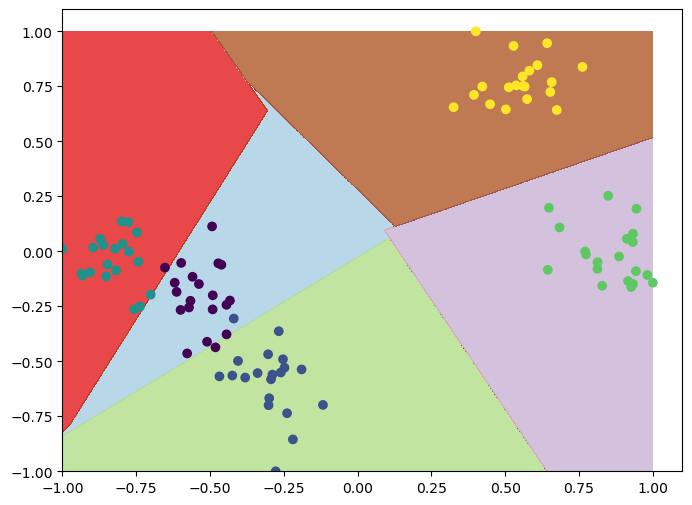

In [14]:
# Linear: 
plotPredictions(svc)

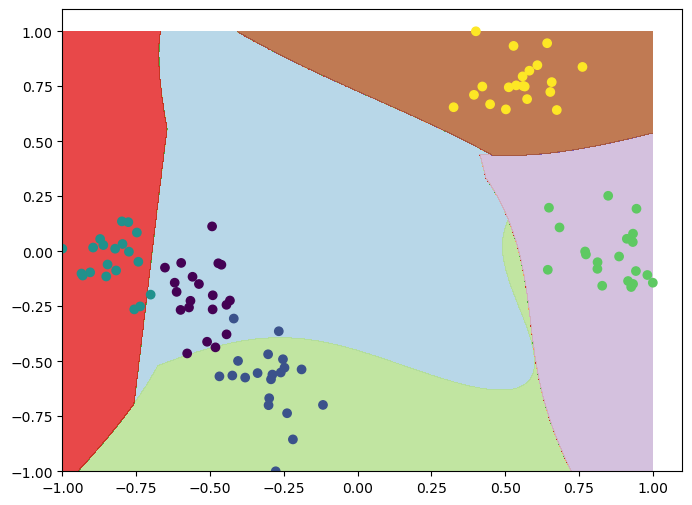

In [15]:
# Poly:
from sklearn import svm, datasets

C = 1.0
svc = svm.SVC(kernel='poly', C=C).fit(X, y)
plotPredictions(svc)

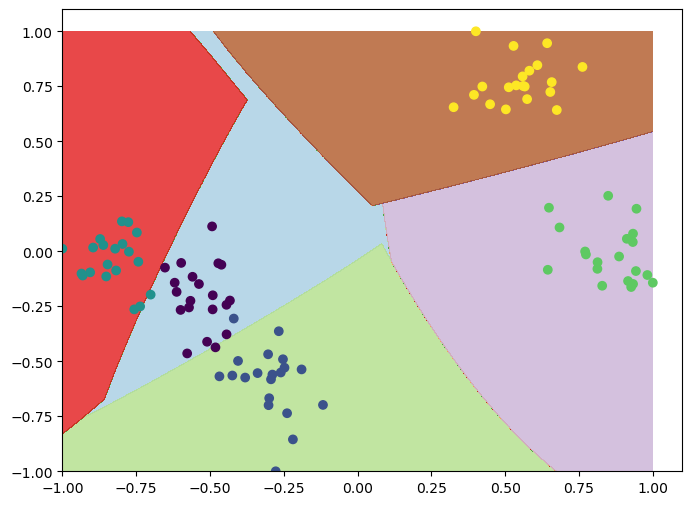

In [16]:
# rbf:
from sklearn import svm, datasets

C = 1.0
svc = svm.SVC(kernel='rbf', C=C).fit(X, y)
plotPredictions(svc)

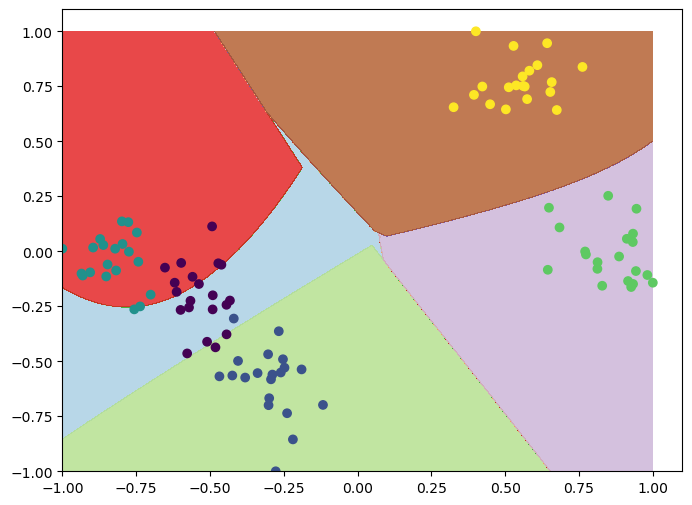

In [17]:
#The types are: ‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’
# sigmoid:
from sklearn import svm, datasets

C = 1.0
svc = svm.SVC(kernel='sigmoid', C=C).fit(X, y)
plotPredictions(svc)

In [19]:
#The types are: ‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’
# precomputed :

# from sklearn import svm, datasets

# C = 1.0
# svc = svm.SVC(kernel='precomputed', C=C).fit(X, y)
# plotPredictions(svc)

print('Precomputed')
print("Can't do it: input must be a square matrix, but we have two 100 row datasets (100x2 matrix)") 

Precomputed
Can't do it: input must be a square matrix, but we have two 100 row datasets (100x2 matrix)


Or just use predict for a given point:

In [32]:
outcome = svc.predict(scaling.transform([[200000, 40]]))
print(outcome)
print(scaling.inverse_transform(outcome - outcome.min()))

[3]


ValueError: Expected 2D array, got 1D array instead:
array=[0.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [21]:
print(svc.predict(scaling.transform([[50000, 65]])))

[2]


## Activity

"Linear" is one of many kernels scikit-learn supports on SVC. Look up the documentation for scikit-learn online to find out what the other possible kernel options are. Do any of them work well for this data set?